In [1]:
# 导入库
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import math
import time 

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# --- 1. 加载数据 ---
# 导入数据
try:
    column_names = ['date', 'pollution', 'dew', 'temp', 'press', 'wnd_dir', 'wnd_spd', 'snow', 'rain']
    df = pd.read_csv('D:\\Codes\\code\\py\\PRML\\assignment3_2\\LSTM-Multivariate_pollution.csv', names=column_names, header=0, parse_dates=['date'], index_col='date')
except FileNotFoundError:
    print("错误：请确保 'LSTM-Multivariate_pollution.csv' 文件在当前目录下。")

print("数据加载完成:")
print(df.head())


数据加载完成:
                     pollution  dew  temp   press wnd_dir  wnd_spd  snow  rain
date                                                                          
2010-01-02 00:00:00      129.0  -16  -4.0  1020.0      SE     1.79     0     0
2010-01-02 01:00:00      148.0  -15  -4.0  1020.0      SE     2.68     0     0
2010-01-02 02:00:00      159.0  -11  -5.0  1021.0      SE     3.57     0     0
2010-01-02 03:00:00      181.0   -7  -5.0  1022.0      SE     5.36     1     0
2010-01-02 04:00:00      138.0   -7  -5.0  1022.0      SE     6.25     2     0


In [4]:
# --- 2. 数据预处理 ---

# 处理缺失值
if 'pollution' in df.columns:
    print(f"\n处理前 'pollution' 列缺失值数量: {df['pollution'].isnull().sum()}")
    df['pollution'].fillna(method='ffill', inplace=True)
    df['pollution'].fillna(0, inplace=True)
    print(f"处理后 'pollution' 列缺失值数量: {df['pollution'].isnull().sum()}")
else:
    print("警告：数据中未找到 'pollution' 列。")
    exit()

# 进行编码
print(f"\n处理前的 'wnd_dir' 列值: {df['wnd_dir'].unique()}")
df = pd.get_dummies(df, columns=['wnd_dir'], prefix='wnd')
print("\n进行 One-Hot Encoding 后的列名:")
print(df.columns)

# 扩展列名和原始特征数量
target_col_name = 'pollution'
if target_col_name not in df.columns:
    print(f"错误：列 '{target_col_name}' 不在 DataFrame 中。可用列：{df.columns}")
    exit()
original_features = df.columns.tolist()
n_features = len(original_features)
target_column_index = original_features.index(target_col_name)
print(f"Target column '{target_col_name}' is at index: {target_column_index}")
print(f"Total features after encoding: {n_features}")

# 将值转换为float和scale
values = df.values.astype('float32')
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

# 创建序列函数
def create_sequences(data, n_steps_in, n_steps_out, target_column_index):
    X, y = [], []
    for i in range(len(data)):
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out - 1
        if out_end_ix >= len(data):
            break
        seq_x = data[i:end_ix, :]
        seq_y = data[out_end_ix, target_column_index] # Get the specific target value
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

n_steps = 3 

# 创建训练和测试序列
X_np, y_np = create_sequences(scaled_values, n_steps, 1, target_column_index)
print(f"\nNumPy 序列形状: X={X_np.shape}, y={y_np.shape}")



处理前 'pollution' 列缺失值数量: 0
处理后 'pollution' 列缺失值数量: 0

处理前的 'wnd_dir' 列值: ['SE' 'cv' 'NW' 'NE']

进行 One-Hot Encoding 后的列名:
Index(['pollution', 'dew', 'temp', 'press', 'wnd_spd', 'snow', 'rain',
       'wnd_NE', 'wnd_NW', 'wnd_SE', 'wnd_cv'],
      dtype='object')
Target column 'pollution' is at index: 0
Total features after encoding: 11

NumPy 序列形状: X=(43797, 3, 11), y=(43797,)


C:\Users\Starrism\AppData\Local\Temp\ipykernel_48796\4109962206.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['pollution'].fillna(method='ffill', inplace=True)
C:\Users\Starrism\AppData\Local\Temp\ipykernel_48796\4109962206.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['pollution'].fillna(method='ffill', inplace=True)
C:\Users\Starrism\AppData\Local\Temp\ipykernel_48796\4109962206.py:7: FutureWarning: A value is trying to

In [5]:
# --- 3. 划分数据集 & 转换为 PyTorch Tensors ---
n_samples = X_np.shape[0]
train_size = int(n_samples * 0.8)
test_size = n_samples - train_size

X_train_np, X_test_np = X_np[:train_size], X_np[train_size:]
y_train_np, y_test_np = y_np[:train_size], y_np[train_size:]

# 转换为 PyTorch Tensors
X_train = torch.from_numpy(X_train_np).float()
y_train = torch.from_numpy(y_train_np).float().unsqueeze(1) # Target needs shape (batch, 1) for MSELoss
X_test = torch.from_numpy(X_test_np).float()
y_test = torch.from_numpy(y_test_np).float().unsqueeze(1)

print(f"\nPyTorch Tensor 形状:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")



PyTorch Tensor 形状:
X_train: torch.Size([35037, 3, 11]), y_train: torch.Size([35037, 1])
X_test: torch.Size([8760, 3, 11]), y_test: torch.Size([8760, 1])


In [6]:
# --- 4. 创建 DataLoaders ---
batch_size = 72 

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # shuffle=False for time series

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoader BATCH_SIZE={batch_size}")



DataLoader BATCH_SIZE=72


In [7]:

# --- 5. 定义 LSTM 模型 (PyTorch) ---
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_prob=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout_prob if num_layers > 1 else 0) 
                        
        
        self.dropout = nn.Dropout(dropout_prob)
        
        self.fc = nn.Linear(hidden_size, output_size)

    # 前向传播
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # 通过lstm层
        out, _ = self.lstm(x, (h0, c0))

        out = out[:, -1, :] 
        # 取最后一个时间步的输出
        out = self.dropout(out)

        # 全连接层
        out = self.fc(out) 
        return out

# 创建模型实例
input_size = n_features   
hidden_size = 50         
num_layers = 2             
output_size = 1            

model = LSTMModel(input_size, hidden_size, num_layers, output_size, dropout_prob=0.2).to(device)

print("\nPyTorch LSTM 模型结构:")
print(model)



PyTorch LSTM 模型结构:
LSTMModel(
  (lstm): LSTM(11, 50, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [8]:

# --- 6. 定义损失函数和优化器 ---
criterion = nn.MSELoss() # 绝对值均值loss
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam 优化器


In [9]:

# --- 7. 训练模型 ---
num_epochs = 50 
train_losses = []
print("\n开始训练模型...")
start_time = time.time()

model.train() 
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for i, (inputs, targets) in enumerate(train_loader):
        # 数据移动到GPU 
        inputs = inputs.to(device)
        targets = targets.to(device)

        # 前向传播
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # 反向传播和优化
        optimizer.zero_grad() 
        loss.backward()       
        optimizer.step()      

        epoch_loss += loss.item()

    # 计算平均损失
    avg_epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)
    if (epoch + 1) % 10 == 0 or epoch == 0: 
      print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.6f}')

training_time = time.time() - start_time
print(f"\n模型训练完成. 耗时: {training_time:.2f} 秒")



开始训练模型...
Epoch [1/50], Loss: 0.006229
Epoch [10/50], Loss: 0.000918
Epoch [20/50], Loss: 0.000853
Epoch [30/50], Loss: 0.000818
Epoch [40/50], Loss: 0.000792
Epoch [50/50], Loss: 0.000772

模型训练完成. 耗时: 61.60 秒


In [10]:
# --- 8. 评估模型 ---
print("\n在测试集上评估模型...")
model.eval()
test_predictions = []
test_actuals = []

with torch.no_grad(): 
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)

        # 转换
        test_predictions.append(outputs.cpu().numpy())
        test_actuals.append(targets.cpu().numpy())

y_pred_scaled_np = np.concatenate(test_predictions, axis=0).flatten()
y_test_actual_scaled_np = np.concatenate(test_actuals, axis=0).flatten()

# 计算测试集的损失
test_loss_scaled = mean_squared_error(y_test_actual_scaled_np, y_pred_scaled_np)
test_mae_scaled = mean_absolute_error(y_test_actual_scaled_np, y_pred_scaled_np)
print(f"测试集损失 (Scaled MSE): {test_loss_scaled:.6f}")
print(f"测试集平均绝对误差 (Scaled MAE): {test_mae_scaled:.6f}")




在测试集上评估模型...
测试集损失 (Scaled MSE): 0.001381
测试集平均绝对误差 (Scaled MAE): 0.028386



反归一化预测结果...

评估反归一化后的预测结果:
反归一化后 - 测试集均方根误差 (RMSE): 36.93
反归一化后 - 测试集平均绝对误差 (MAE): 28.22


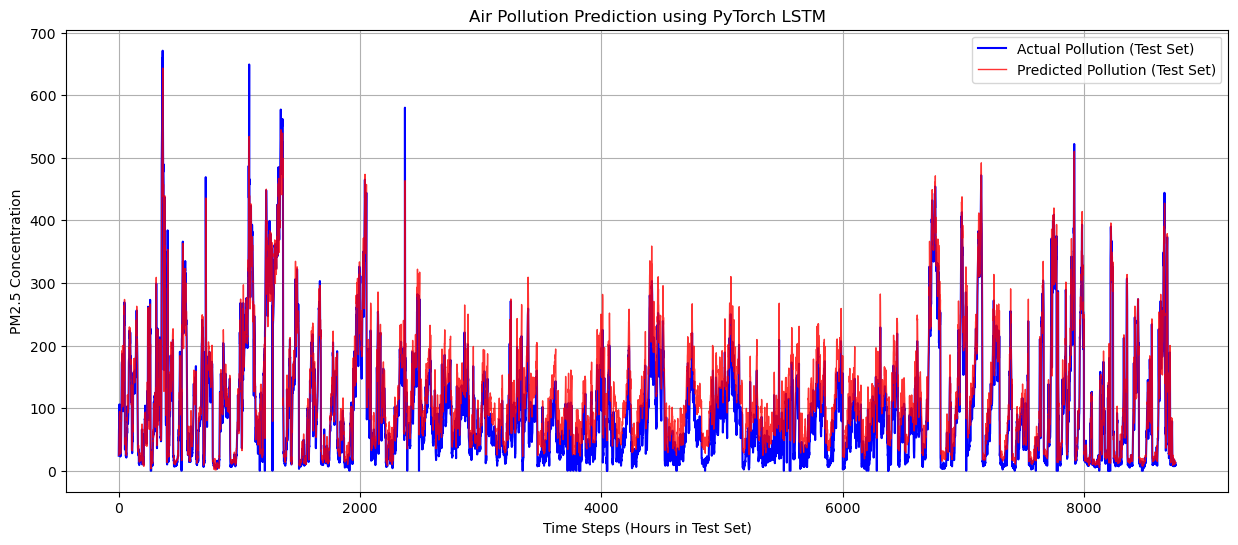

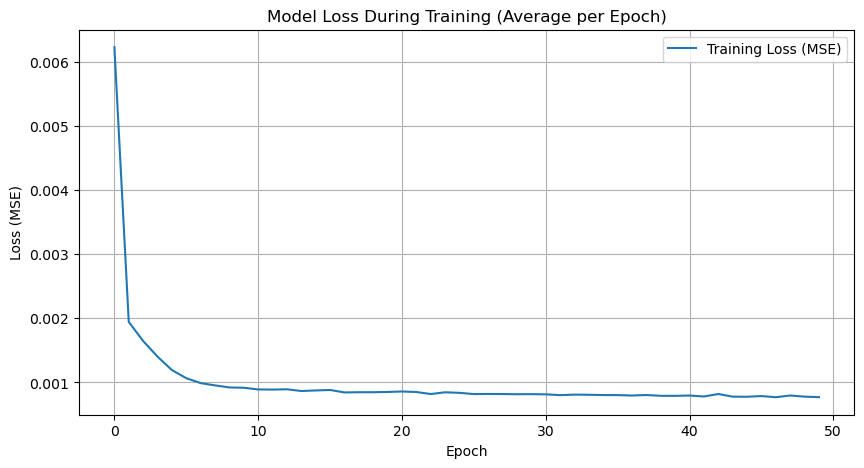

In [11]:

# --- 9. 结果反归一化 ---
print("\n反归一化预测结果...")

inv_pred_dummy = np.zeros((len(y_pred_scaled_np), n_features))
inv_test_dummy = np.zeros((len(y_test_actual_scaled_np), n_features))

inv_pred_dummy[:, target_column_index] = y_pred_scaled_np
inv_test_dummy[:, target_column_index] = y_test_actual_scaled_np

y_pred_actual = scaler.inverse_transform(inv_pred_dummy)[:, target_column_index]
y_test_actual = scaler.inverse_transform(inv_test_dummy)[:, target_column_index]


# --- 评估反归一化后的结果 ---
print("\n评估反归一化后的预测结果:")
rmse_actual = math.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)
print(f"反归一化后 - 测试集均方根误差 (RMSE): {rmse_actual:.2f}")
print(f"反归一化后 - 测试集平均绝对误差 (MAE): {mae_actual:.2f}")


# --- 可视化结果  ---
plt.figure(figsize=(15, 6))
plt.plot(y_test_actual, label='Actual Pollution (Test Set)', color='blue', linewidth=1.5)
plt.plot(y_pred_actual, label='Predicted Pollution (Test Set)', color='red', alpha=0.8, linewidth=1)
plt.title('Air Pollution Prediction using PyTorch LSTM')
plt.xlabel('Time Steps (Hours in Test Set)')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.grid(True)
plt.show()

# 可视化训练过程中的损失 
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss (MSE)')
# Note: Validation loss wasn't explicitly calculated per epoch in this loop,
# but you could add a validation step within the epoch loop if desired.
plt.title('Model Loss During Training (Average per Epoch)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()